# 01 — Chemistry + Field: TP-3310, TP-3320, TP-3340

**Run All** (or run each cell top → bottom with Shift+Enter).

| Step | What |
|------|------|
| 1 | Setup — find project root, check Excel paths |
| 2 | Dioxane — SAMPLE RESULTS sheets → removal Y (lab qualifier applied) |
| 2b | **All FIELD DATA** (pH, temp, ammonia, TSS, …) + **all SAMPLE RESULTS** co-contaminants |
| 3 | Plot 2025 chemistry + field |

**Lab qualifier (`FINAL Q`) handling:** `R` (rejected) rows dropped; `U` (non-detect) Result is the reporting limit → substituted with **half the limit**; `J`/`NJ` (estimated) kept as reported.

**Data:** `data/raw/Prof_Miller_chemistry_03092026/`

## Step 1 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import re

%matplotlib inline


def find_project_root() -> Path:
    """Walk up from cwd until we find data/raw (works from any subfolder)."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find project root. Open/run notebook from DIOPredict LOWRY folder."
    )


PROJECT_ROOT = find_project_root()
CHEM_DIR = PROJECT_ROOT / "data/raw/Prof_Miller_chemistry_03092026"
OUT_DIR = PROJECT_ROOT / "data/processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_FILES = {
    "3310": CHEM_DIR / "TP-3310 SEDIMENTATION TANK.xlsx",
    "3320": CHEM_DIR / "TP-3320 BLEND TANK.xlsx",
    "3340": CHEM_DIR / "TP-3340 EFFLUENT.xlsx",
}

for loc, path in EXCEL_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {loc} file: {path}")

print("Project root:", PROJECT_ROOT)
print("Chemistry folder:", CHEM_DIR)
print("Excel files OK:", list(EXCEL_FILES.keys()))

Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY
Chemistry folder: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/raw/Prof_Miller_chemistry_03092026
Excel files OK: ['3310', '3320', '3340']


## Step 2 — Load & merge (3310 + 3320 + 3340 by date)

In [2]:
def apply_qualifier(df, value_col="value"):
    """Respect the FINAL Q lab qualifier (SAMPLE RESULTS only).

    - R  (rejected):    drop row
    - U  (non-detect):  Result = reporting limit → use half the limit (half-DL)
    - J/NJ (estimated): keep as reported
    """
    if "FINAL Q" not in df.columns:
        return df
    q = df["FINAL Q"].astype(str).str.strip().str.upper()
    df = df[~q.eq("R")].copy()
    q = df["FINAL Q"].astype(str).str.strip().str.upper()
    nd = q.eq("U")
    df.loc[nd, value_col] = df.loc[nd, value_col] / 2.0
    return df


def load_dioxane_excel(path: Path, location: str) -> pd.DataFrame:
    """Read 1,4-dioxane rows from the SAMPLE RESULTS sheet (qualifier-aware)."""
    xls = pd.ExcelFile(path)
    sheet = next(s for s in xls.sheet_names if "SAMPLE RESULTS" in s.upper())
    df = pd.read_excel(path, sheet_name=sheet)

    diox = df[
        df["Parameter Name"].astype(str).str.contains("dioxane", case=False, na=False)
    ].copy()
    diox["date"] = pd.to_datetime(diox["Sample Date"], errors="coerce").dt.normalize()
    diox["value"] = pd.to_numeric(diox["Result"], errors="coerce")
    diox = apply_qualifier(diox)
    diox["dioxane_ugL"] = diox["value"]
    diox["location"] = location

    out = diox[["date", "location", "dioxane_ugL"]].dropna(subset=["date", "dioxane_ugL"])
    return out.groupby(["date", "location"], as_index=False)["dioxane_ugL"].mean()


tall = pd.concat(
    [load_dioxane_excel(p, loc) for loc, p in EXCEL_FILES.items()],
    ignore_index=True,
)

wide = tall.pivot(index="date", columns="location", values="dioxane_ugL")
wide = wide.rename(
    columns={"3310": "dioxane_3310", "3320": "dioxane_3320", "3340": "dioxane_3340"}
)
wide = wide.sort_index()

# Y candidate: plant removal % (needs both 3310 and 3340)
wide["removal_3310_3340"] = (
    (wide["dioxane_3310"] - wide["dioxane_3340"]) / wide["dioxane_3310"] * 100
)

print(f"Total unique dates (any port): {len(wide)}")
print(
    f"Dates with all 3 ports: "
    f"{wide.dropna(subset=['dioxane_3310', 'dioxane_3320', 'dioxane_3340']).shape[0]}"
)
print(
    f"Dates with 3310 + 3340 (removal Y): "
    f"{wide.dropna(subset=['dioxane_3310', 'dioxane_3340']).shape[0]}"
)

wide_2025 = wide[wide.index.year == 2025]
print(f"\n2025 dates (any port): {len(wide_2025)}")
print("\nLast 10 rows (2025):")
print(wide_2025.tail(10).to_string())

out_path = OUT_DIR / "bts_chemistry_3310_3320_3340.csv"
wide.reset_index().to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

Total unique dates (any port): 1245
Dates with all 3 ports: 1075
Dates with 3310 + 3340 (removal Y): 1076

2025 dates (any port): 42

Last 10 rows (2025):
location    dioxane_3310  dioxane_3320  dioxane_3340  removal_3310_3340
date                                                                   
2025-07-08       55000.0        1100.0         120.0          99.781818
2025-07-15       49000.0         550.0          68.0          99.861224
2025-07-22       22000.0        1400.0          51.0          99.768182
2025-07-29       34000.0        1300.0          46.0          99.864706
2025-08-04       26000.0           NaN           NaN                NaN
2025-08-05       40000.0        1400.0          75.0          99.812500
2025-08-12       41000.0        1300.0          61.0          99.851220
2025-08-19       24000.0        1400.0         100.0          99.583333
2025-08-26       11000.0         660.0          55.0          99.500000
2025-09-02       27000.0        1400.0          54.0 

## Step 2b — All field + sample chemistry (full Prof. Miller Excel features)


In [3]:
import re


def param_slug(name: str) -> str:
    """Stable column slug; keep legacy pH_/temp_ names."""
    n = str(name).strip()
    if n.lower() == "ph":
        return "pH"
    if "temperature" in n.lower():
        return "temp"
    slug = re.sub(r"[^a-zA-Z0-9]+", "_", n).strip("_").lower()
    return slug[:80]


def load_all_field_excel(path: Path, location: str) -> pd.DataFrame:
    """All numeric parameters from FIELD DATA sheet (no FINAL Q column here)."""
    xls = pd.ExcelFile(path)
    sheet = next(s for s in xls.sheet_names if "FIELD DATA" in s.upper())
    df = pd.read_excel(path, sheet_name=sheet)
    df = df.copy()
    df["date"] = pd.to_datetime(df["Sample Date"], errors="coerce").dt.normalize()
    df["value"] = pd.to_numeric(df["Result"], errors="coerce")
    df["param"] = df["Parameter Name"].astype(str).str.strip()
    df["location"] = location
    out = df.dropna(subset=["date", "value", "param"])
    return out.groupby(["date", "location", "param"], as_index=False)["value"].mean()


def load_all_sample_excel(path: Path, location: str) -> pd.DataFrame:
    """All numeric SAMPLE RESULTS except dioxane; qualifier-aware (R drop, U half-DL)."""
    xls = pd.ExcelFile(path)
    sheet = next(s for s in xls.sheet_names if "SAMPLE RESULTS" in s.upper())
    df = pd.read_excel(path, sheet_name=sheet)
    df = df.copy()
    df["date"] = pd.to_datetime(df["Sample Date"], errors="coerce").dt.normalize()
    df["value"] = pd.to_numeric(df["Result"], errors="coerce")
    df["param"] = df["Parameter Name"].astype(str).str.strip()
    df["location"] = location
    df = apply_qualifier(df)
    df = df[~df["param"].str.contains("dioxane", case=False, na=False)]
    out = df.dropna(subset=["date", "value", "param"])
    return out.groupby(["date", "location", "param"], as_index=False)["value"].mean()


def pivot_features(tall: pd.DataFrame, prefix: str) -> pd.DataFrame:
    tall = tall.copy()
    tall["col"] = prefix + tall["param"].map(param_slug) + "_" + tall["location"]
    tall = tall.groupby(["date", "col"], as_index=False)["value"].mean()
    return tall.pivot(index="date", columns="col", values="value").sort_index()


field_tall = pd.concat(
    [load_all_field_excel(p, loc) for loc, p in EXCEL_FILES.items()],
    ignore_index=True,
)
field_wide = pivot_features(field_tall, prefix="")
field_rename = {
    c: c if c.startswith(("pH_", "temp_")) else f"field_{c}"
    for c in field_wide.columns
}
field_wide = field_wide.rename(columns=field_rename)

sample_tall = pd.concat(
    [load_all_sample_excel(p, loc) for loc, p in EXCEL_FILES.items()],
    ignore_index=True,
)
sample_wide = pivot_features(sample_tall, prefix="sr_")

combined = wide.join(field_wide, how="left").join(sample_wide, how="left")
combined = combined.sort_index()
combined_2025 = combined[combined.index.year == 2025]

field_cols = [c for c in combined.columns if c.startswith(("pH_", "temp_", "field_"))]
sample_cols = [c for c in combined.columns if c.startswith("sr_")]

print(f"Field columns: {len(field_cols)}")
print(f"Sample-results columns: {len(sample_cols)}")
print(f"Total feature columns (excl. dioxane Y): {len(field_cols) + len(sample_cols)}")
print(f"Dates with any field data: {combined[field_cols].notna().any(axis=1).sum() if field_cols else 0}")
print(f"Dates with any sample chemistry: {combined[sample_cols].notna().any(axis=1).sum() if sample_cols else 0}")

show_cols = ["dioxane_3310", "removal_3310_3340", "pH_3310", "field_nitrogen_ammonia_3310", "sr_benzene_3310", "sr_tetrahydrofuran_3310"]
show_cols = [c for c in show_cols if c in combined.columns]
print(f"\n2025 sample (last 3 rows, key cols):")
print(combined_2025[show_cols].tail(3).to_string())

combined_path = OUT_DIR / "bts_chemistry_field_by_date.csv"
combined.reset_index().to_csv(combined_path, index=False)
print(f"\nSaved: {combined_path}")

Field columns: 10
Sample-results columns: 320
Total feature columns (excl. dioxane Y): 330
Dates with any field data: 1130
Dates with any sample chemistry: 1231

2025 sample (last 3 rows, key cols):
            dioxane_3310  removal_3310_3340  pH_3310  field_nitrogen_ammonia_3310  sr_benzene_3310  sr_tetrahydrofuran_3310
date                                                                                                                       
2025-08-19       24000.0          99.583333     6.56                        134.6           1100.0                  26000.0
2025-08-26       11000.0          99.500000     6.28                         27.4             45.0                   2300.0
2025-09-02       27000.0          99.800000     6.34                        123.6            240.0                  16000.0

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/bts_chemistry_field_by_date.csv


## Step 3 — Plot 2025 (chemistry + field)


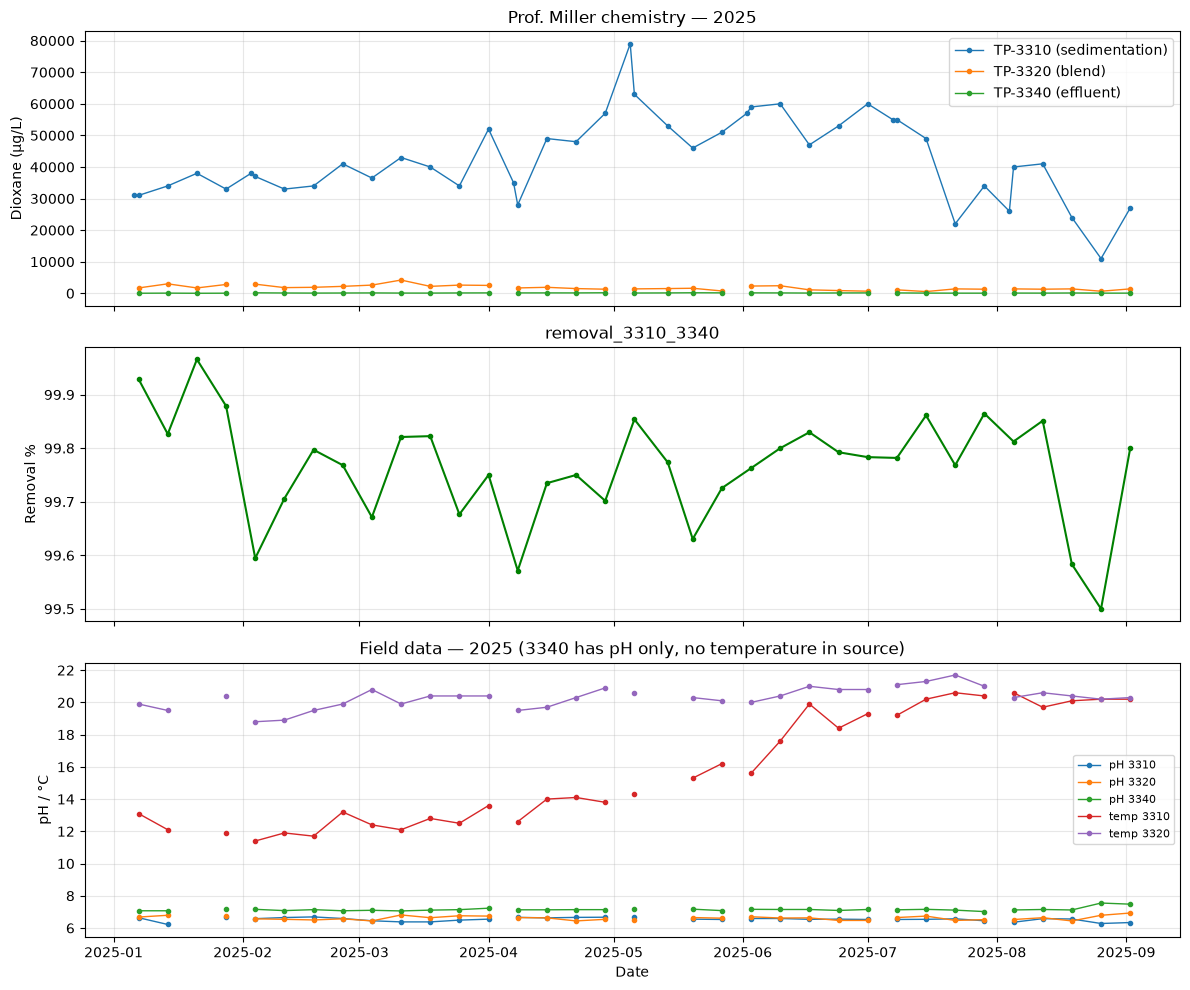

In [4]:
plot_df = combined_2025.copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for col, label in [
    ("dioxane_3310", "TP-3310 (sedimentation)"),
    ("dioxane_3320", "TP-3320 (blend)"),
    ("dioxane_3340", "TP-3340 (effluent)"),
]:
    if col in plot_df.columns:
        axes[0].plot(
            plot_df.index, plot_df[col], marker="o", markersize=3, linewidth=1, label=label
        )
axes[0].set_ylabel("Dioxane (µg/L)")
axes[0].set_title("Prof. Miller chemistry — 2025")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rem = plot_df["removal_3310_3340"].dropna()
if not rem.empty:
    axes[1].plot(rem.index, rem, color="green", marker="o", markersize=3)
axes[1].set_ylabel("Removal %")
axes[1].set_title("removal_3310_3340")
axes[1].grid(True, alpha=0.3)

for col, label in [
    ("pH_3310", "pH 3310"),
    ("pH_3320", "pH 3320"),
    ("pH_3340", "pH 3340"),
    ("temp_3310", "temp 3310"),
    ("temp_3320", "temp 3320"),
]:
    if col in plot_df.columns and plot_df[col].notna().any():
        axes[2].plot(
            plot_df.index, plot_df[col], marker="o", markersize=3, linewidth=1, label=label
        )
axes[2].set_ylabel("pH / °C")
axes[2].set_xlabel("Date")
axes[2].set_title("Field data — 2025 (3340 has pH only, no temperature in source)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()